In [ ]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import src.utils as utils


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >

<h1>Notebook EDA de MovieLens</h1>

<h2>Sélection de la source 
</h2>

Modifier uniquement la constante `DATA_SOURCE` dans la cellule suivante.

Sources disponibles :
- `raw_small` -> `data/raw_small` (CSV)
- `raw_big` -> `data/raw_big` (CSV)
- `processed_small` -> `data/processed/small` (Parquet)
- `processed_big` -> `data/processed/big` (Parquet)

Exemple :
- `DATA_SOURCE = "raw_small"`

</div>

In [10]:

DATA_SOURCE = "raw_small"

# Configuration de la source, Path.cwd() récupère le dossier courant.
project_root = utils.get_project_root()

dataset_format, path_ratings, path_movies = utils.resolve_data_source_paths(
    DATA_SOURCE, project_root=project_root
)

print(f"Racine projet: {project_root}")
print(f"Source: {DATA_SOURCE}")
print(f"Format: {dataset_format}")
print(f"ratings: {path_ratings}")
print(f"movies: {path_movies}")

Racine projet: /Users/brunocoulet/Documents/projets/sparkle-movie
Source: raw_small
Format: csv
ratings: /Users/brunocoulet/Documents/projets/sparkle-movie/data/raw_small/ratings.csv
movies: /Users/brunocoulet/Documents/projets/sparkle-movie/data/raw_small/movies.csv


In [12]:
# Initialisation Spark et chargement de la source sélectionnée
spark = utils.create_spark_session()
df_ratings, df_movies, dataset_format, path_ratings, path_movies = utils.load_data_source(
    spark, DATA_SOURCE, project_root=project_root
)

print(f"DataFrames chargés avec succès depuis {DATA_SOURCE} ({dataset_format}).")

DataFrames chargés avec succès depuis raw_small (csv).


In [13]:
# Aperçu de la structure et des 10 premières lignes
print("--- Schema ratings ---")
df_ratings.printSchema()
print("--- Top 10 ratings ---")
df_ratings.show(10, truncate=False)

print("--- Schema movies ---")
df_movies.printSchema()
print("--- Top 10 movies ---")
df_movies.show(10, truncate=False)

--- Schema ratings ---
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

--- Top 10 ratings ---
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
|1     |70     |3.0   |964982400|
|1     |101    |5.0   |964980868|
|1     |110    |4.0   |964982176|
|1     |151    |5.0   |964984041|
|1     |157    |5.0   |964984100|
+------+-------+------+---------+
only showing top 10 rows

--- Schema movies ---
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

--- Top 10 movies ---
+-------+----------------------------------+-------------------------------------------+
|movieId|title                       

<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Nettoyage des donnees</h2>
On applique `clean_data` pour retirer les valeurs manquantes critiques et les doublons.
</div>

In [14]:
# Nettoyage des DataFrames
df_ratings_clean, df_movies_clean = utils.clean_data(df_ratings, df_movies)

print("Lignes ratings avant/apres:", df_ratings.count(), "/", df_ratings_clean.count())
print("Lignes movies avant/apres:", df_movies.count(), "/", df_movies_clean.count())

Lignes ratings avant/apres: 100836 / 100836
Lignes movies avant/apres: 9742 / 9742


<div style="color: #849dc9; background-color: #223f4d; padding: 10px; border-radius: 8px;" >
<h2>Tendances generales</h2>
On calcule le top des films par note moyenne (avec seuil minimal de votes) et les genres les plus populaires.

In [15]:
# Top films et genres populaires
df_top_movies = utils.top_rated_movies(df_ratings_clean, df_movies_clean)
df_top_genres = utils.most_popular_genres(df_ratings_clean, df_movies_clean)

print("--- Top 10 films les mieux notes (min 50 votes) ---")
df_top_movies.show(10, truncate=False)

print("--- Top 10 genres les plus populaires ---")
df_top_genres.show(10, truncate=False)

--- Top 10 films les mieux notes (min 50 votes) ---
+-------+---------------------------------------------------------------------------+-----------------+---------+
|movieId|title                                                                      |avg_rating       |n_ratings|
+-------+---------------------------------------------------------------------------+-----------------+---------+
|318    |Shawshank Redemption, The (1994)                                           |4.429022082018927|317      |
|858    |Godfather, The (1972)                                                      |4.2890625        |192      |
|2959   |Fight Club (1999)                                                          |4.272935779816514|218      |
|1276   |Cool Hand Luke (1967)                                                      |4.271929824561403|57       |
|750    |Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)|4.268041237113402|97       |
|904    |Rear Window (1954)         

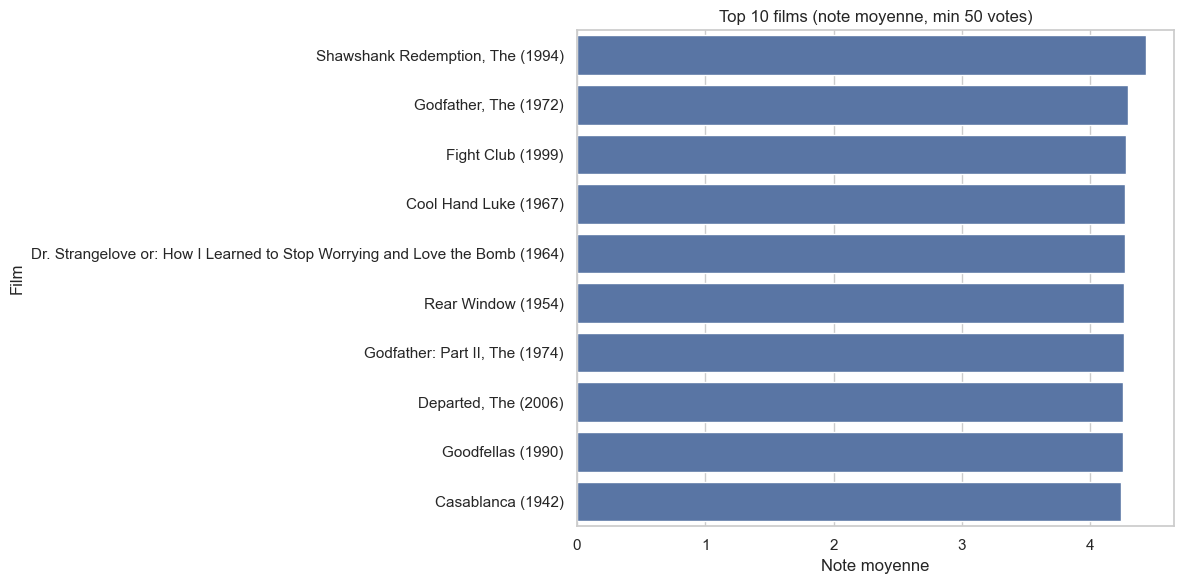

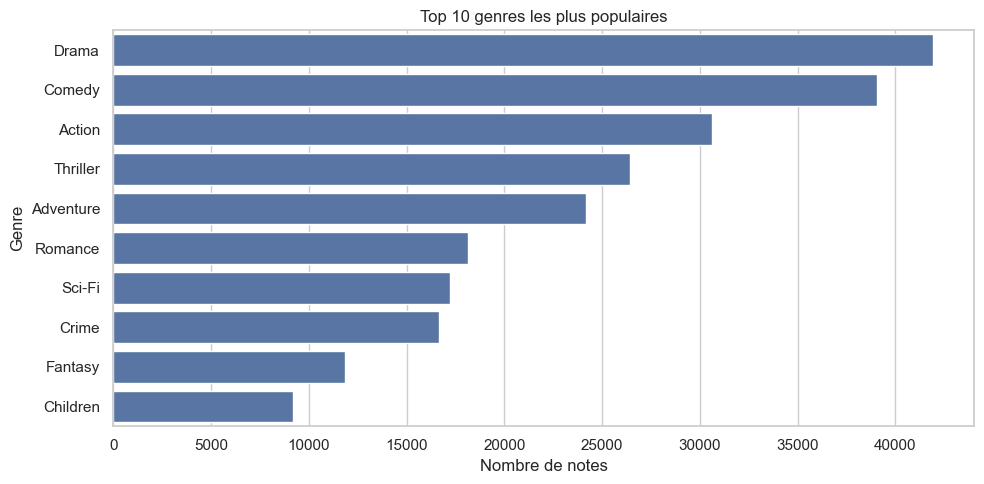

In [16]:
# Visualisations
utils.plot_results(df_top_movies, df_top_genres)

In [17]:
# Libération propre de la session Spark
spark.stop()
print("Session Spark arrêtée.")

Session Spark arrêtée.
